### Random walks and image segmentation

Via simple examples we visualise the use of random walks for image segmentation<!-- .slide: data-fullscreen -->

At the beginning, images are represented as a grid networks of pixels, each one having a color value. 

By making the walkers avoid neighbour pixels that are too `different` from the one they're on, we are forcing them to stay in the same region of the image, thus segmenting it.


In [1]:
import random as rand
import numpy as np

import matplotlib.pyplot as plt

from PIL import Image

Let's look at the benckmark image seen in class, a B29 Stratofortress flying over a cloudy sky: can we automatically detect it?

That is image 3096 the [Berkley Segmentation Dataset and Benchmark](https://www2.eecs.berkeley.edu/Research/Projects/CS/vision/bsds/)

The image below (a JPG version of the original PNG image) is $481\times 321=154,401$ pixels in size.


 A simplified dataset it the [BSD68 benckmark dataset](https://github.com/clausmichele/CBSD68-dataset/tree/master) which is a collection of images with a ground truth-segmentation mask that is used to benchmark *denoising*

![](https://raw.githubusercontent.com/clausmichele/CBSD68-dataset/master/CBSD68/groundtruth/airplane.png)

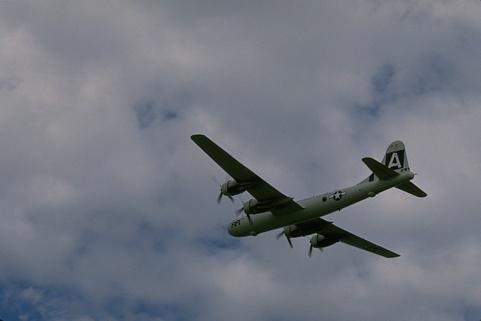

Find the original image and some example segmentations at [eecs.berkeley.edu/Research/Projects/CS/vision/bsds/BSDS300/html/dataset/images/color/3096.html](https://www2.eecs.berkeley.edu/Research/Projects/CS/vision/bsds/BSDS300/html/dataset/images/color/3096.html)

In [2]:
IMGFILE = './imgs/0000.png'

In [ ]:
bitmap = Image.open(IMGFILE)

matrix = np.array(bitmap)

print(matrix.shape)

In [4]:
shape_2d = matrix.shape[:2]
n_rows, n_cols = shape_2d

Compute, for each pixel, its immediate neighbors. There are normally 4 adjacient pixels, except for those on the edges which have only 3, and the corner pixels with 2.

In [5]:
transitions = {}

# possible directions: left, right, below, above
directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

In [6]:
# Loop through each element
for row in range(n_rows):
    for col in range(n_cols):
        neighbors = []
        
        for dir_row, dir_col in directions:
            next_row, next_col = row + dir_row, col + dir_col
        
            # Check if neighbor is within bounds
            if 0 <= next_row < n_rows and 0 <= next_col < n_cols:
                
                neighbors.append((next_row, next_col))
        
        transitions[(row, col)] = neighbors

What happens at the corners?

In [ ]:
print(transitions[0, 0])
print(transitions[n_rows-1, n_cols-1])

#### Compute the colour pixel Norms

Each pixel is assigneed a colour norm, normalised to 0..1, which captures it *brightness* with the formula seen in the slides:

$|p_{ij}|_3 = \frac{1}{\sqrt{3}} \sqrt{\frac{p^{red}_{ij}+p^{green}_{ij}+p^{blue}_{ij}}{255}}$

In [9]:
# another matrix, this time to hold the normalized RGB values
rgb_sum = matrix.astype(np.float32).sum(axis=2)

norm = (1 / np.sqrt(3)) * np.sqrt(rgb_sum / 255)

Now compute the difference, in colour norms, between each pixel and its direct neighbors. 

The respective values, sometimes called *the colour gradient,* will guide the random walkers.

In [10]:
diff_dict = {}

for (row, col), neighbors in transitions.items():
    current_norm = norm[row, col]
    
    diffs = []
    
    for neighbor_row, neighbor_col in neighbors:
        neighbor_norm = norm[neighbor_row, neighbor_col]
        diff = abs(current_norm - neighbor_norm)
        diffs.append(diff)
        
    diff_dict[(row, col)] = diffs

Now transform colour gradients into probabilities that the random walker will transition to each neighbor.

To avoid division-by-zero issues, a small constant is added to the denomitor.

In [11]:
EPSILON = 1e-8

In [12]:
normalized_diff_dict = {}


for key, diff_list in diff_dict.items():
    diff_array = np.array(diff_list, dtype=np.float32)

    # Invert gradients
    score_array = np.round(1.0 / (diff_array + EPSILON), 2)

    total = score_array.sum()
    
    prob_array = score_array / total
    
    normalized_diff_dict[key] = prob_array.tolist()

#### Random Walks

Now random walkers will move around the image, starting at random pixels and moving around following the transition probabilities we set up above, which are based on the colour gradients.

In [13]:
WALKERS = 100_000

# Length of the walk
STEPS = 2_000

In [14]:
# record walks
counter_dict = {elem: 0 for elem in transitions}

pixels = list(counter_dict.keys())

The cell below may take several minutes to run: each of the `WALKERS` walkers will take `STEPS`

we keep track of visits by continuosly updating the relative `counter_dict` position.

In [15]:

for _ in range(WALKERS):
    # land the walker somewhere
    curr_pixel = rand.choice(pixels)
    counter_dict[curr_pixel] += 1

    for _ in range(STEPS):
        neighbors = transitions[curr_pixel]
        indexes = list(range(len(neighbors)))
        
        prob_distr = normalized_diff_dict[curr_pixel]
        
        # where is the walker going to go next?
        choice = rand.choices(indexes, weights=prob_distr)[0]
        curr_pixel = neighbors[choice]
        
        counter_dict[curr_pixel] += 1

Scores are normalised to the maximum number of visits a pixel has received.

We thus write out a sort of *heatmap* that renders the normalised frequecies of walkers' visits.

In [16]:
heatmap = np.zeros((n_rows, n_cols))

for (row, col), value in counter_dict.items():
    heatmap[row, col] = value

heatmap /= heatmap.max()

#### Visualisation

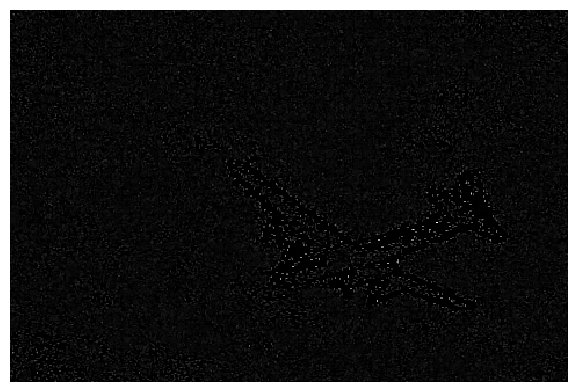

In [17]:
plt.matshow(heatmap, cmap='gray')

plt.axis('off')
plt.show()

With `matshow` we can apply a coloring strategy to improve the visualisation of the segments.

Reference: [matplotlib.org/stable/users/explain/colors/colormaps.html](https://matplotlib.org/stable/users/explain/colors/colormaps.html)

Try out, e.g., `viridis` and `inferno`.

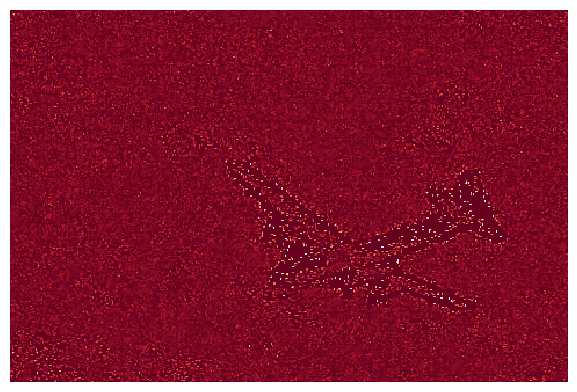

In [85]:
plt.matshow(heatmap, cmap='RdBu', interpolation='nearest')

plt.axis('off')
plt.show()